In [ ]:
import numpy as np
import inspect
from scipy.optimize import minimize

def rosenbrock(X, a=1, b=100):
    x, y = X
    return (a - x)**2 + b * (y - x**2)**2

def rosenbrock_grad(X, a=1, b=100):
    x, y = X
    return np.array([
        2 * (x - a) - 4 * b * x * (y - x**2),
        2 * b * (y - x**2)
    ])

def rosenbrock_hess(X, a=1, b=100):
    x, y = X
    return np.matrix([
        [2 - 4 * b * (y - 3 * x**2), -4 * b * x],
        [-4 * b * x, 2 * b]
    ])

def callback(intermediate_result):
    sf = inspect.stack()[3].frame.f_locals["sf"]
    print(f"{intermediate_result.fun=}")
    print(f"{sf.nfev=}, {sf.ngev=}")

x0 = np.array([5, 1.1], dtype=np.double)

sol = minimize(rosenbrock, x0, jac=rosenbrock_grad, method="L-BFGS-B", callback=callback, options={"disp": True, "maxiter": 10})
# sol = minimize(rosenbrock, x0, jac=rosenbrock_grad, hess=rosenbrock_hess, method="Newton-CG", callback=callback, options={"disp": True, "maxiter": 10})
print(sol)

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# def rosenbrock(x):
#     return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# def rosenbrock_grad(x):
#     dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
#     dfdy = 200 * (x[1] - x[0]**2)
#     return np.array([dfdx, dfdy])

# def rosenbrock_hessian(x):
#     h11 = 2 - 400 * x[1] + 1200 * x[0]**2
#     h12 = -400 * x[0]
#     h21 = -400 * x[0]
#     h22 = 200
#     return np.array([[h11, h12], [h21, h22]])

# def solve_subproblem_cauchy(g, B, delta):
#     g_norm = np.linalg.norm(g)
#     if g_norm < 1e-10:
#         return np.array([0.0, 0.0])
#     Bg_dot_g = np.dot(g, np.dot(B, g))
#     if Bg_dot_g <= 1e-10:
#         alpha_star = delta / g_norm
#     else:
#         alpha_star = min(g_norm**2 / Bg_dot_g, delta / g_norm)
#     p_c = -alpha_star * g
#     return p_c

# def trust_region_optimizer(func, grad, hessian, x0, initial_delta=1.0, max_iter=100,
#                            eta1=0.25, eta2=0.75, gamma1=0.5, gamma2=2.0, epsilon=1e-6):
#     x_k = np.array(x0, dtype=float)
#     delta_k = initial_delta
#     path = [x_k.copy()]
#     deltas = [delta_k]
#     rhos_history = []

#     for k in range(max_iter):
#         g_k = grad(x_k)
#         B_k = hessian(x_k)

#         if np.linalg.norm(g_k) < epsilon:
#             print(f"Converged at iteration {k} with gradient norm {np.linalg.norm(g_k):.2e}")
#             break

#         try:
#             p_k = solve_subproblem_cauchy(g_k, B_k, delta_k)
#         except np.linalg.LinAlgError:
#             print(f"Singular Hessian at iteration {k}. Aborting optimization.")
#             break

#         if np.linalg.norm(p_k) < 1e-10:
#             print(f"Step is effectively zero at iteration {k}. Converged or stuck.")
#             break

#         x_trial = x_k + p_k
#         ared = func(x_k) - func(x_trial)
#         pred = -(np.dot(g_k, p_k) + 0.5 * np.dot(p_k, np.dot(B_k, p_k)))

#         if pred <= 1e-10:
#             rho_k = 0.0
#         else:
#             rho_k = ared / pred

#         rhos_history.append(rho_k)

#         if rho_k < eta1:
#             delta_k *= gamma1
#             path.append(x_k.copy())  # No move, but radius changed
#             deltas.append(delta_k)
#         else:
#             x_k = x_trial
#             if rho_k > eta2:
#                 delta_k *= gamma2
#             path.append(x_k.copy())
#             deltas.append(delta_k)

#     rhos_padded = [np.nan] + rhos_history  # Pad for initial step
#     return x_k, np.array(path), np.array(deltas), np.array(rhos_padded)

# # --- Optimization setup ---
# initial_point = np.array([-2.0, -2.0])
# initial_radius = 0.05
# radius_shrinking_factor = 0.5
# radius_growing_factor = 1.2
# rho_shrinking_threshold = 0.25
# rho_growing_threshold = 0.75
# max_iterations = 200

# final_point, path, deltas, rhos_padded = trust_region_optimizer(
#     rosenbrock, rosenbrock_grad, rosenbrock_hessian,
#     x0=initial_point,
#     initial_delta=initial_radius,
#     eta1=rho_shrinking_threshold,
#     eta2=rho_growing_threshold,
#     gamma1=radius_shrinking_factor,
#     gamma2=radius_growing_factor,
#     max_iter=max_iterations
# )

# print(f"\nOptimization finished.")
# print(f"Number of iterations (steps with rho): {len(rhos_padded)-1}")
# print(f"Total points in path: {len(path)}")
# print(f"Final point: {final_point}")
# print(f"Rosenbrock value at final: {rosenbrock(final_point):.2e}")

# # --- Animation setup ---
# fig, ax = plt.subplots(figsize=(8, 6))
# x = np.linspace(-2.5, 2.5, 400)
# y = np.linspace(-3, 3, 400)
# X, Y = np.meshgrid(x, y)
# Z = rosenbrock(np.array([X, Y]))
# contour = ax.contour(X, Y, Z, levels=np.logspace(0, 3, 15), cmap='viridis')
# ax.clabel(contour, inline=True, fontsize=8, fmt='%1.0f')
# ax.set_xlim(-2.5, 2.5)
# ax.set_ylim(-3, 3)
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_title('Trust Region Optimization of Rosenbrock Function')

# line, = ax.plot([], [], 'k-o', markersize=4)
# current_point_marker, = ax.plot([], [], 'go', markersize=8)
# iter_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)
# delta_text = ax.text(0.02, 0.90, '', transform=ax.transAxes)
# rho_text = ax.text(0.02, 0.85, '', transform=ax.transAxes)
# trust_region_circle = plt.Circle(path[0], deltas[0], color='blue', alpha=0.3)
# ax.add_patch(trust_region_circle)

# def init():
#     line.set_data([], [])
#     current_point_marker.set_data([], [])
#     iter_text.set_text('')
#     delta_text.set_text('')
#     rho_text.set_text('')
#     trust_region_circle.set_radius(deltas[0])
#     trust_region_circle.center = (path[0,0], path[0,1])
#     return line, current_point_marker, iter_text, delta_text, rho_text, trust_region_circle

# import traceback

# def update(frame):
#     idx = frame if frame < len(path) else len(path) - 1

#     line.set_data(path[:idx+1, 0], path[:idx+1, 1])
#     current_point_marker.set_data([path[idx, 0]], [path[idx, 1]])  # <-- fix here
#     trust_region_circle.set_radius(deltas[idx])
#     trust_region_circle.center = (path[idx, 0], path[idx, 1])
#     iter_text.set_text(f'Iteration: {idx}')
#     delta_text.set_text(f'Delta: {deltas[idx]:.3f}')

#     if idx < len(rhos_padded):
#         rho_val = rhos_padded[idx]
#     else:
#         rho_val = np.nan

#     rho_text.set_text(f'Rho: {rho_val:.3f}' if not np.isnan(rho_val) else 'Rho: N/A')

#     if not np.isnan(rho_val):
#         if rho_val < rho_shrinking_threshold:
#             trust_region_circle.set_edgecolor('red')
#             trust_region_circle.set_facecolor('red')
#             trust_region_circle.set_alpha(0.2)
#         elif rho_val > rho_growing_threshold:
#             trust_region_circle.set_edgecolor('green')
#             trust_region_circle.set_facecolor('green')
#             trust_region_circle.set_alpha(0.2)
#         else:
#             trust_region_circle.set_edgecolor('blue')
#             trust_region_circle.set_facecolor('blue')
#             trust_region_circle.set_alpha(0.3)
#     else:
#         trust_region_circle.set_edgecolor('blue')
#         trust_region_circle.set_facecolor('blue')
#         trust_region_circle.set_alpha(0.3)

#     return line, current_point_marker, iter_text, delta_text, rho_text, trust_region_circle

# # Try saving with fewer frames to debug
# limited_frames = min(50, len(path) - 1)

# ani = FuncAnimation(fig, update, frames=limited_frames, init_func=init,
#                     blit=False, repeat=False, interval=200)

# print("Saving animation (limited frames)... This might take a moment.")
# try:
#     ani.save('trust_region_optimization_debug.gif', writer='pillow', fps=10)
#     print("Animation saved successfully!")
# except Exception as e:
#     print(f"Failed to save animation: {e}")
#     traceback.print_exc()


# plt.show()



Optimization finished.
Number of iterations (steps with rho): 200
Total points in path: 201
Final point: [0.85183111 0.72559297]
Rosenbrock value at final: 2.20e-02
Selected illustrative points indices:
- initial: 0
- grow: 29
- shrink_pos_rho: 23


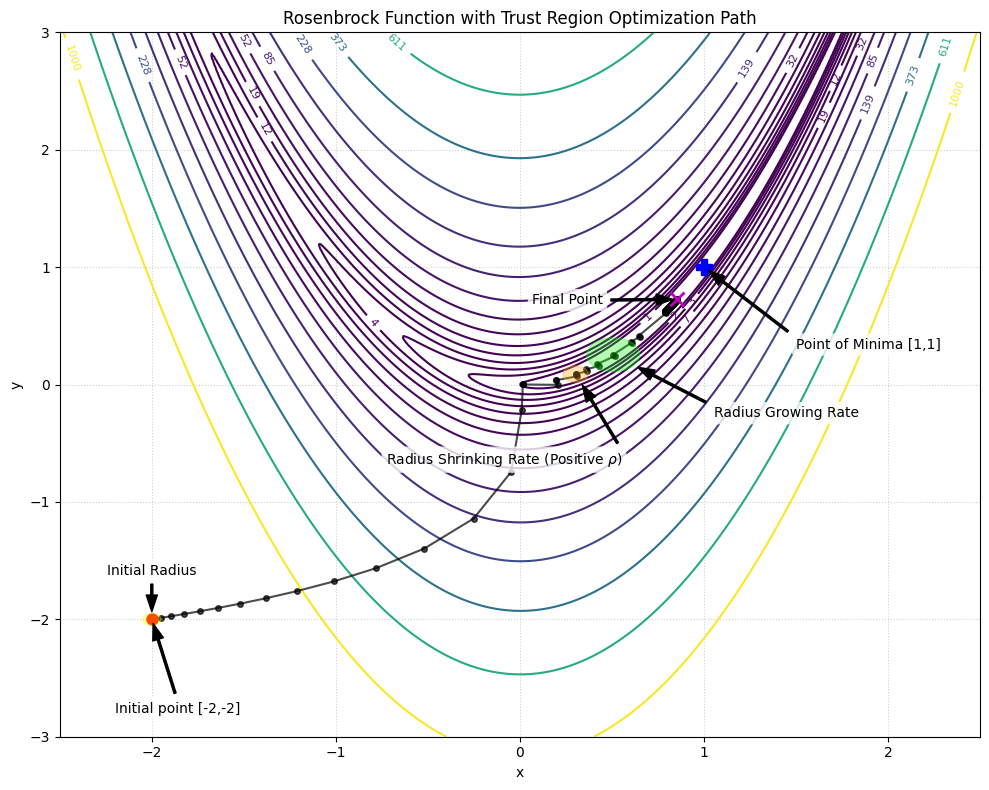

Saving animation... This might take a moment.
Animation saved successfully!


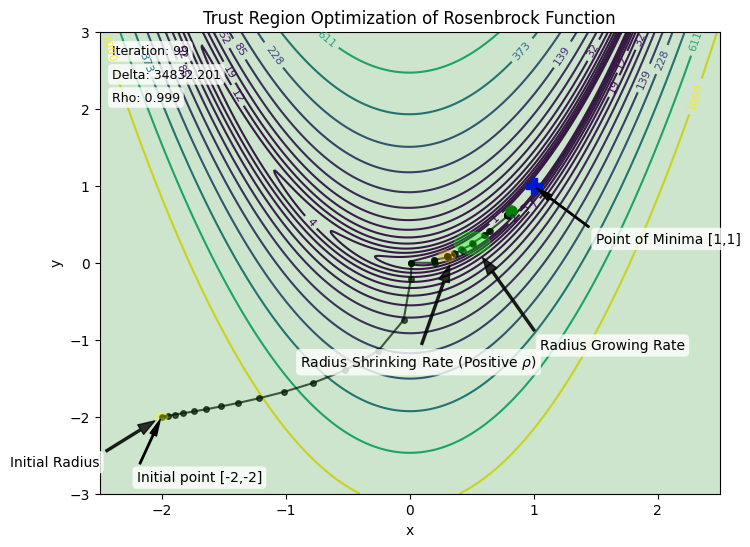

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import traceback

# --- Rosenbrock Function and its Derivatives ---
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def rosenbrock_grad(x):
    dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dfdy = 200 * (x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

def rosenbrock_hessian(x):
    h11 = 2 - 400 * x[1] + 1200 * x[0]**2
    h12 = -400 * x[0]
    h21 = -400 * x[0]
    h22 = 200
    return np.array([[h11, h12], [h21, h22]])

# --- Trust Region Subproblem Solver (Cauchy Point) ---
def solve_subproblem_cauchy(g, B, delta):
    g_norm = np.linalg.norm(g)
    if g_norm < 1e-10:
        return np.array([0.0, 0.0])
    Bg_dot_g = np.dot(g, np.dot(B, g))
    if Bg_dot_g <= 1e-10: # Avoid division by zero or negative values
        alpha_star = delta / g_norm
    else:
        alpha_star = min(g_norm**2 / Bg_dot_g, delta / g_norm)
    p_c = -alpha_star * g
    return p_c

# --- Trust Region Optimization Algorithm ---
def trust_region_optimizer(func, grad, hessian, x0, initial_delta=1.0, max_iter=100,
                           eta1=0.25, eta2=0.75, gamma1=0.5, gamma2=2.0, epsilon=1e-6):
    x_k = np.array(x0, dtype=float)
    delta_k = initial_delta
    path = [x_k.copy()]
    deltas = [delta_k]
    rhos_history = []

    for k in range(max_iter):
        g_k = grad(x_k)
        B_k = hessian(x_k)

        if np.linalg.norm(g_k) < epsilon:
            print(f"Converged at iteration {k} with gradient norm {np.linalg.norm(g_k):.2e}")
            break

        try:
            p_k = solve_subproblem_cauchy(g_k, B_k, delta_k)
        except np.linalg.LinAlgError:
            print(f"Singular Hessian at iteration {k}. Aborting optimization.")
            break

        if np.linalg.norm(p_k) < 1e-10:
            print(f"Step is effectively zero at iteration {k}. Converged or stuck.")
            break

        x_trial = x_k + p_k
        ared = func(x_k) - func(x_trial)
        pred = -(np.dot(g_k, p_k) + 0.5 * np.dot(p_k, np.dot(B_k, p_k)))

        if pred <= 1e-10: # Avoid division by zero or negative predicted reduction
            rho_k = 0.0
        else:
            rho_k = ared / pred

        rhos_history.append(rho_k)

        if rho_k < eta1:
            delta_k *= gamma1
            path.append(x_k.copy()) # No move, but radius changed for next step
            deltas.append(delta_k)
        else:
            x_k = x_trial
            if rho_k > eta2:
                delta_k *= gamma2
            path.append(x_k.copy())
            deltas.append(delta_k)

    # Pad rhos with NaN for the initial state where rho isn't calculated yet
    rhos_padded = [np.nan] + rhos_history
    return x_k, np.array(path), np.array(deltas), np.array(rhos_padded)

# --- Optimization Setup ---
initial_point = np.array([-2.0, -2.0])
initial_radius = 0.05
radius_shrinking_factor = 0.5
radius_growing_factor = 1.2
rho_shrinking_threshold = 0.25 # eta1
rho_growing_threshold = 0.75   # eta2
max_iterations = 200

final_point, path, deltas, rhos_padded = trust_region_optimizer(
    rosenbrock, rosenbrock_grad, rosenbrock_hessian,
    x0=initial_point,
    initial_delta=initial_radius,
    eta1=rho_shrinking_threshold,
    eta2=rho_growing_threshold,
    gamma1=radius_shrinking_factor,
    gamma2=radius_growing_factor,
    max_iter=max_iterations
)

print(f"\nOptimization finished.")
print(f"Number of iterations (steps with rho): {len(rhos_padded)-1}")
print(f"Total points in path: {len(path)}")
print(f"Final point: {final_point}")
print(f"Rosenbrock value at final: {rosenbrock(final_point):.2e}")

# --- Plotting the Rosenbrock Function ---
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = rosenbrock(np.array([X, Y]))

# --- Helper to find illustrative points for radius changes ---
def find_illustrative_points(path, deltas, rhos_padded, rho_shrinking_threshold, rho_growing_threshold):
    points = {
        'initial': {'idx': 0, 'label': 'Initial Radius'},
        'grow': {'idx': -1, 'label': 'Radius Growing Rate'},
        'shrink_pos_rho': {'idx': -1, 'label': 'Radius Shrinking Rate (Positive $\\rho$)'},
    }

    found_grow = False
    found_shrink_pos = False

    # Search for positive rho shrinking, ensuring it's not too close to initial point
    # and has subsequent points for vector calculation. Start from index 3 to allow prev/next points.
    for i in range(3, len(rhos_padded) - 1): # -1 to ensure path[i+1] exists
        current_rho = rhos_padded[i]
        delta_changed = abs(deltas[i] - deltas[i-1]) > 1e-6 
        
        if not found_shrink_pos and delta_changed and 0 <= current_rho < rho_shrinking_threshold:
            points['shrink_pos_rho']['idx'] = i
            found_shrink_pos = True
            break 

    # Search for grow, ensuring it's at least 5 steps after shrinking (if found)
    # and has subsequent points for vector calculation. Start from index 3 or after shrink point.
    min_dist_from_shrink_pos = 5 
    start_grow_search = 3 if not found_shrink_pos else points['shrink_pos_rho']['idx'] + min_dist_from_shrink_pos
    
    for i in range(max(3, start_grow_search), len(rhos_padded) - 1): 
        current_rho = rhos_padded[i]
        delta_changed = abs(deltas[i] - deltas[i-1]) > 1e-6 

        if not found_grow and delta_changed and current_rho > rho_growing_threshold:
            points['grow']['idx'] = i
            found_grow = True
            break
            
    # Fallback if specific points are still not found for illustration (allowing last point if needed)
    if points['shrink_pos_rho']['idx'] == -1:
        for i in range(1, len(rhos_padded)): # Search up to the very last available rho
            if 0 <= rhos_padded[i] < rho_shrinking_threshold:
                points['shrink_pos_rho']['idx'] = i
                break
    if points['grow']['idx'] == -1:
        for i in range(1, len(rhos_padded)): # Search up to the very last available rho
            if rhos_padded[i] > rho_growing_threshold:
                points['grow']['idx'] = i
                break

    print(f"Selected illustrative points indices:")
    for key, val in points.items():
        print(f"- {key}: {val['idx']}")
            
    return points

illustrative_points = find_illustrative_points(path, deltas, rhos_padded, rho_shrinking_threshold, rho_growing_threshold)

# --- Helper function for perpendicular offset ---
def get_perpendicular_offset(current_point, prev_point, next_point, offset_distance=0.4):
    """
    Calculates an offset vector perpendicular to the path at current_point.
    Chooses the 'outward' pointing perpendicular vector relative to the minima (1,1).
    """
    # Determine the direction vector of the path segment
    if np.array_equal(current_point, prev_point) and not np.array_equal(current_point, next_point): # Initial point of path (or no movement yet)
        direction_vector = next_point - current_point
    elif np.array_equal(current_point, next_point) and not np.array_equal(current_point, prev_point): # Final point of path
        direction_vector = current_point - prev_point
    elif not np.array_equal(prev_point, next_point): # Intermediate point
        direction_vector = next_point - prev_point
    else: # Fallback if direction is ambiguous (e.g., path is stationary)
        # If no clear movement, default to top-right quadrant from current_point
        return np.array([offset_distance, offset_distance]) 

    norm = np.linalg.norm(direction_vector)
    if norm < 1e-9: # If points are too close, direction is undefined
        return np.array([offset_distance, offset_distance]) # Fallback to a fixed direction

    direction_vector = direction_vector / norm # Normalize tangent vector

    # Two possible perpendicular vectors
    perp_vec1 = np.array([-direction_vector[1], direction_vector[0]])
    perp_vec2 = np.array([direction_vector[1], -direction_vector[0]])

    # Target point to determine 'outward' direction (e.g., the true minima)
    target_point = np.array([1.0, 1.0])
    
    # Vector from current point to target
    vec_current_to_target = target_point - current_point

    # Choose the perpendicular vector that points more 'away' from the target
    # by checking the dot product: a larger dot product means more alignment.
    # We want the one less aligned (or negatively aligned) towards the target.
    dot1 = np.dot(perp_vec1, vec_current_to_target)
    dot2 = np.dot(perp_vec2, vec_current_to_target)

    # Pick the vector that has a smaller (more negative) dot product with vec_current_to_target.
    # This means it points more away from the target.
    if dot1 < dot2:
        selected_perp_vector = perp_vec1
    else:
        selected_perp_vector = perp_vec2
    
    return selected_perp_vector * offset_distance

# --- Helper to set horizontal/vertical alignment based on offset vector ---
def get_alignment(offset_vec, threshold=0.1):
    ha = 'center'
    va = 'center'

    if offset_vec[0] > threshold:
        ha = 'left'
    elif offset_vec[0] < -threshold:
        ha = 'right'
    
    if offset_vec[1] > threshold:
        va = 'bottom'
    elif offset_vec[1] < -threshold:
        va = 'top'
    
    return ha, va

# --- Static Plot with Labeled Features ---
plt.figure(figsize=(10, 8))
ax_static = plt.subplot(111)

# Contour plot
contour_static = ax_static.contour(X, Y, Z, levels=np.logspace(0, 3, 15), cmap='viridis')
ax_static.clabel(contour_static, inline=True, fontsize=8, fmt='%1.0f')

ax_static.set_xlim(-2.5, 2.5)
ax_static.set_ylim(-3, 3)
ax_static.set_xlabel('x')
ax_static.set_ylabel('y')
ax_static.set_title('Rosenbrock Function with Trust Region Optimization Path')

# Plot the optimization path
ax_static.plot(path[:, 0], path[:, 1], 'k-o', markersize=4, alpha=0.7, label='Optimization Path')
ax_static.plot(1, 1, 'bP', markersize=12, label='True Minima [1,1]') # Actual minima

bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8)

# --- Annotations and Circles for Static Plot ---

# Initial Point
ax_static.plot(path[0, 0], path[0, 1], 'ro', markersize=8)
ax_static.annotate('Initial point [-2,-2]', xy=(path[0,0], path[0,1]),
                   xytext=(-2.2, -2.7),
                   arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                   fontsize=10, color='black', ha='left', va='top',
                   bbox=bbox_props)

# Initial Radius - STATIC PLOT CUSTOMIZATION
if illustrative_points['initial']['idx'] != -1 and illustrative_points['initial']['idx'] + 1 < len(path):
    idx = illustrative_points['initial']['idx']
    initial_circle = plt.Circle(path[idx], deltas[idx], color='yellow', alpha=0.3, zorder=2)
    ax_static.add_patch(initial_circle)

    # Custom position for the label on the top side of the initial circle
    text_xy = np.array([path[idx,0], path[idx,1] + deltas[idx] + 0.3]) # Directly above the circle, slightly offset

    # Calculate arrow tip on the circle's circumference, pointing from text_xy
    vec_center_to_text = text_xy - path[idx]
    if np.linalg.norm(vec_center_to_text) > 1e-9:
        normalized_direction_to_text = vec_center_to_text / np.linalg.norm(vec_center_to_text)
        arrow_xy_tip = path[idx] + normalized_direction_to_text * deltas[idx]
    else: # Fallback if text_xy is too close to center
        arrow_xy_tip = (path[idx,0], path[idx,1] + deltas[idx]) # Default to directly top
    
    # Custom alignment for the label
    ha = 'center'
    va = 'bottom'

    ax_static.annotate('Initial Radius', xy=arrow_xy_tip,
                       xytext=text_xy,
                       arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                       fontsize=10, color='black', ha=ha, va=va,
                       bbox=bbox_props)


# Radius Growing Rate
if illustrative_points['grow']['idx'] != -1 and illustrative_points['grow']['idx'] > 0 and illustrative_points['grow']['idx'] + 1 < len(path):
    idx = illustrative_points['grow']['idx']
    grow_circle = plt.Circle(path[idx], deltas[idx], color='lime', alpha=0.3, zorder=2)
    ax_static.add_patch(grow_circle)

    text_offset_vector = get_perpendicular_offset(path[idx], path[idx-1], path[idx+1], offset_distance=0.7)
    text_xy = path[idx] + text_offset_vector

    vec_center_to_text = text_xy - path[idx]
    if np.linalg.norm(vec_center_to_text) > 1e-9:
        normalized_direction_to_text = vec_center_to_text / np.linalg.norm(vec_center_to_text)
        arrow_xy_tip = path[idx] + normalized_direction_to_text * deltas[idx]
    else:
        arrow_xy_tip = (path[idx,0] + deltas[idx]*0.707, path[idx,1] + deltas[idx]*0.707)
    
    ha, va = get_alignment(text_offset_vector)

    ax_static.annotate('Radius Growing Rate', xy=arrow_xy_tip,
                       xytext=text_xy,
                       arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                       fontsize=10, color='black', ha=ha, va=va,
                       bbox=bbox_props)

# Radius Shrinking Rate (Positive Rho)
if illustrative_points['shrink_pos_rho']['idx'] != -1 and illustrative_points['shrink_pos_rho']['idx'] > 0 and illustrative_points['shrink_pos_rho']['idx'] + 1 < len(path):
    idx = illustrative_points['shrink_pos_rho']['idx']
    shrink_pos_circle = plt.Circle(path[idx], deltas[idx], color='orange', alpha=0.3, zorder=2)
    ax_static.add_patch(shrink_pos_circle)
    
    text_offset_vector = get_perpendicular_offset(path[idx], path[idx-1], path[idx+1], offset_distance=0.7)
    text_xy = path[idx] + text_offset_vector

    vec_center_to_text = text_xy - path[idx]
    if np.linalg.norm(vec_center_to_text) > 1e-9:
        normalized_direction_to_text = vec_center_to_text / np.linalg.norm(vec_center_to_text)
        arrow_xy_tip = path[idx] + normalized_direction_to_text * deltas[idx]
    else:
        arrow_xy_tip = (path[idx,0] - deltas[idx]*0.707, path[idx,1] - deltas[idx]*0.707) # Default to bottom-left
    
    ha, va = get_alignment(text_offset_vector)
    # Potentially override for specific label if default is not ideal for visual flow
    if ha == 'left': ha = 'right' 
    if va == 'bottom': va = 'top' 

    ax_static.annotate('Radius Shrinking Rate (Positive $\\rho$)', xy=arrow_xy_tip,
                       xytext=text_xy,
                       arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                       fontsize=10, color='black', ha=ha, va=va,
                       bbox=bbox_props)

# Final Point
ax_static.plot(final_point[0], final_point[1], 'mx', markersize=10, mew=2)
if len(path) > 1:
    idx_final = len(path) -1
    current_pt = path[idx_final]
    prev_pt = path[idx_final-1]
    # For final point, 'next_point' is current_pt itself, indicating end of path
    text_offset_vector = get_perpendicular_offset(current_pt, prev_pt, current_pt, offset_distance=0.4)
else: # If path has only one point
    text_offset_vector = np.array([0.4, 0.4])

text_xy_final = final_point + text_offset_vector
ha_final, va_final = get_alignment(text_offset_vector)

ax_static.annotate('Final Point', xy=(final_point[0], final_point[1]),
                   xytext=text_xy_final,
                   arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                   fontsize=10, color='black', ha=ha_final, va=va_final,
                   bbox=bbox_props)

# Point of Minima annotation
ax_static.annotate('Point of Minima [1,1]', xy=(1, 1),
                   xytext=(1.0 + 0.5, 1.0 - 0.6), # Adjusted further to bottom-right of minima
                   arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                   fontsize=10, color='black', ha='left', va='top',
                   bbox=bbox_props)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Animation Setup ---
fig_anim, ax_anim = plt.subplots(figsize=(8, 6))
contour_anim = ax_anim.contour(X, Y, Z, levels=np.logspace(0, 3, 15), cmap='viridis')
ax_anim.clabel(contour_anim, inline=True, fontsize=8, fmt='%1.0f')
ax_anim.set_xlim(-2.5, 2.5)
ax_anim.set_ylim(-3, 3)
ax_anim.set_xlabel('x')
ax_anim.set_ylabel('y')
ax_anim.set_title('Trust Region Optimization of Rosenbrock Function')

line, = ax_anim.plot([], [], 'k-o', markersize=4, alpha=0.7)
current_point_marker, = ax_anim.plot([], [], 'go', markersize=8)
minima_marker, = ax_anim.plot(1, 1, 'bP', markersize=12) # Mark the true minima

# Text for iteration, delta, rho (dynamic)
iter_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes, fontsize=9, bbox=bbox_props)
delta_text = ax_anim.text(0.02, 0.90, '', transform=ax_anim.transAxes, fontsize=9, bbox=bbox_props)
rho_text = ax_anim.text(0.02, 0.85, '', transform=ax_anim.transAxes, fontsize=9, bbox=bbox_props)

# Trust region circle (dynamic color)
trust_region_circle = plt.Circle(path[0], deltas[0], color='blue', alpha=0.3, zorder=2)
ax_anim.add_patch(trust_region_circle)

# --- Static Annotations for Animation (always visible) ---
anim_initial_point_text_fixed = ax_anim.annotate('Initial point [-2,-2]', xy=initial_point, xytext=(-2.2, -2.7),
                                          arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                                          fontsize=10, color='black', bbox=bbox_props, ha='left', va='top')
anim_minima_point_text_fixed = ax_anim.annotate('Point of Minima [1,1]', xy=(1, 1), xytext=(1.0 + 0.5, 1.0 - 0.6),
                                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                                         fontsize=10, color='black', bbox=bbox_props, ha='left', va='top')

# --- Dynamically Appearing Illustrative Circles and Annotations for Animation ---
# Create all objects, initialize them as invisible.
# They will be made visible in update() at specific frames and their properties updated.

# Initial Radius
initial_circle_anim = plt.Circle((0,0), 0, color='yellow', alpha=0.3, zorder=2, visible=False)
ax_anim.add_patch(initial_circle_anim)
arrow_initial_radius = ax_anim.annotate('Initial Radius', xy=(0,0), xytext=(0,0),
                                        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, alpha=0.8),
                                        fontsize=10, color='black', bbox=bbox_props, ha='center', va='center', visible=False)

# Radius Growing Rate
grow_circle_anim = plt.Circle((0,0), 0, color='lime', alpha=0.3, zorder=2, visible=False)
ax_anim.add_patch(grow_circle_anim)
arrow_growing_rate = ax_anim.annotate('Radius Growing Rate', xy=(0,0), xytext=(0,0),
                                       arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, alpha=0.8),
                                       fontsize=10, color='black', bbox=bbox_props, ha='center', va='center', visible=False)

# Radius Shrinking Rate (Positive Rho)
shrink_pos_circle_anim = plt.Circle((0,0), 0, color='orange', alpha=0.3, zorder=2, visible=False)
ax_anim.add_patch(shrink_pos_circle_anim)
arrow_shrinking_pos_rate = ax_anim.annotate('Radius Shrinking Rate (Positive $\\rho$)', xy=(0,0), xytext=(0,0),
                                            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, alpha=0.8),
                                            fontsize=10, color='black', bbox=bbox_props, ha='center', va='center', visible=False)

# Final Point annotation (dynamic)
final_point_marker_anim, = ax_anim.plot([], [], 'mx', markersize=10, mew=2, visible=False)
anim_final_point_text_dynamic = ax_anim.annotate('Final Point', xy=(0,0), xytext=(0,0),
                                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                                         fontsize=10, color='black', bbox=bbox_props, ha='left', va='center', visible=False)

# Global flags to control persistent visibility of dynamic labels
_initial_radius_shown = False
_grow_rate_shown = False
_shrink_pos_rho_shown = False
_final_point_shown = False

def init():
    global _initial_radius_shown, _grow_rate_shown, _shrink_pos_rho_shown, _final_point_shown

    line.set_data([], [])
    current_point_marker.set_data([], [])
    iter_text.set_text('')
    delta_text.set_text('')
    rho_text.set_text('')
    trust_region_circle.set_radius(deltas[0])
    trust_region_circle.set_center((path[0,0], path[0,1]))
    trust_region_circle.set_edgecolor('blue')
    trust_region_circle.set_facecolor('blue')
    trust_region_circle.set_alpha(0.3)

    # Ensure all dynamic illustrative elements are initially invisible
    initial_circle_anim.set_visible(False)
    arrow_initial_radius.set_visible(False)
    grow_circle_anim.set_visible(False)
    arrow_growing_rate.set_visible(False)
    shrink_pos_circle_anim.set_visible(False)
    arrow_shrinking_pos_rate.set_visible(False)
    final_point_marker_anim.set_visible(False)
    anim_final_point_text_dynamic.set_visible(False)

    # Reset flags for a new animation run
    _initial_radius_shown = False
    _grow_rate_shown = False
    _shrink_pos_rho_shown = False
    _final_point_shown = False

    artists = [line, current_point_marker, iter_text, delta_text, rho_text,
               trust_region_circle, anim_initial_point_text_fixed, anim_minima_point_text_fixed,
               initial_circle_anim, arrow_initial_radius,
               grow_circle_anim, arrow_growing_rate,
               shrink_pos_circle_anim, arrow_shrinking_pos_rate,
               final_point_marker_anim, anim_final_point_text_dynamic]

    return tuple(artists)

def update(frame):
    global _initial_radius_shown, _grow_rate_shown, _shrink_pos_rho_shown, _final_point_shown

    idx = frame if frame < len(path) else len(path) - 1

    line.set_data(path[:idx+1, 0], path[:idx+1, 1])
    current_point_marker.set_data([path[idx, 0]], [path[idx, 1]])
    trust_region_circle.set_radius(deltas[idx])
    trust_region_circle.set_center((path[idx, 0], path[idx, 1]))

    iter_text.set_text(f'Iteration: {idx}')
    delta_text.set_text(f'Delta: {deltas[idx]:.3f}')

    rho_val = rhos_padded[idx] if idx < len(rhos_padded) else np.nan
    rho_text.set_text(f'Rho: {rho_val:.3f}' if not np.isnan(rho_val) else 'Rho: N/A (Initial)')

    if not np.isnan(rho_val):
        if rho_val < rho_shrinking_threshold:
            trust_region_circle.set_edgecolor('red')
            trust_region_circle.set_facecolor('red')
            trust_region_circle.set_alpha(0.2)
        elif rho_val > rho_growing_threshold:
            trust_region_circle.set_edgecolor('green')
            trust_region_circle.set_facecolor('green')
            trust_region_circle.set_alpha(0.2)
        else:
            trust_region_circle.set_edgecolor('blue')
            trust_region_circle.set_facecolor('blue')
            trust_region_circle.set_alpha(0.3)
    else:
        trust_region_circle.set_edgecolor('blue')
        trust_region_circle.set_facecolor('blue')
        trust_region_circle.set_alpha(0.3)

    # --- Make illustrative elements visible and update their positions ---
    
    # Initial Radius - ANIMATION CUSTOMIZATION
    if illustrative_points['initial']['idx'] == idx and idx + 1 < len(path):
        _initial_radius_shown = True
    if _initial_radius_shown:
        if illustrative_points['initial']['idx'] == idx:
            current_pt = path[idx]
    
            # Custom text position near bottom-left
            text_xy = current_pt + np.array([-0.5, -0.5])
            arrow_xy_tip = current_pt + np.array([-deltas[idx]*0.6, -deltas[idx]*0.6])  # Shorter arrow
    
            initial_circle_anim.set_center(current_pt)
            initial_circle_anim.set_radius(deltas[idx])
    
            # Correct way to update annotation dynamically
            arrow_initial_radius.set_position(text_xy)     # sets the xytext
            arrow_initial_radius.xy = arrow_xy_tip         # sets the arrow tip
    
            arrow_initial_radius.set_ha('right')
            arrow_initial_radius.set_va('top')
    
        initial_circle_anim.set_visible(True)
        arrow_initial_radius.set_visible(True)



    # Radius Growing Rate
    if illustrative_points['grow']['idx'] == idx and idx > 0 and idx + 1 < len(path):
        _grow_rate_shown = True
    if _grow_rate_shown:
        if illustrative_points['grow']['idx'] == idx:
            current_pt = path[idx]
            prev_pt = path[idx - 1]
            next_pt = path[idx + 1]
    
            # Compute base offset vector
            text_offset_vector = get_perpendicular_offset(current_pt, prev_pt, next_pt, offset_distance=0.7)
    
            # Manually adjust downward to avoid overlapping with shrinking label
            manual_adjustment = np.array([0.0, -0.8])  # Downward shift
            text_xy = current_pt + text_offset_vector + manual_adjustment
    
            # Arrow tip calculation
            vec_center_to_text = text_xy - current_pt
            if np.linalg.norm(vec_center_to_text) > 1e-9:
                normalized_direction_to_text = vec_center_to_text / np.linalg.norm(vec_center_to_text)
                arrow_xy_tip = current_pt + normalized_direction_to_text * deltas[idx]
            else:
                arrow_xy_tip = (current_pt[0] + deltas[idx]*0.707, current_pt[1] + deltas[idx]*0.707)  # Fallback
    
            ha, va = get_alignment(text_offset_vector)
    
            # Apply radius and visibility
            grow_circle_anim.set_center(current_pt)
            grow_circle_anim.set_radius(deltas[idx])
    
            # ✅ Correct way to update annotation
            arrow_growing_rate.set_position(text_xy)     # label position
            arrow_growing_rate.xy = arrow_xy_tip         # arrow tip
            arrow_growing_rate.set_ha(ha)
            arrow_growing_rate.set_va(va)
    
        grow_circle_anim.set_visible(True)
        arrow_growing_rate.set_visible(True)


    # Radius Shrinking Rate (Positive Rho)
    if illustrative_points['shrink_pos_rho']['idx'] == idx and idx > 0 and idx + 1 < len(path):
        _shrink_pos_rho_shown = True
    if _shrink_pos_rho_shown:
        if illustrative_points['shrink_pos_rho']['idx'] == idx:
            current_pt = path[idx]
            prev_pt = path[idx - 1]
            next_pt = path[idx + 1]
    
            # Base perpendicular offset
            text_offset_vector = get_perpendicular_offset(current_pt, prev_pt, next_pt, offset_distance=2.0)
    
            # ✅ Manual northward adjustment
            manual_adjustment = np.array([0.0, 0.6])  # upward shift
            text_xy = current_pt + text_offset_vector + manual_adjustment
    
            vec_center_to_text = text_xy - current_pt
            if np.linalg.norm(vec_center_to_text) > 1e-9:
                normalized_direction_to_text = vec_center_to_text / np.linalg.norm(vec_center_to_text)
                arrow_xy_tip = current_pt + normalized_direction_to_text * deltas[idx]
            else:
                arrow_xy_tip = (current_pt[0] - deltas[idx]*0.707, current_pt[1] - deltas[idx]*0.707)  # Fallback
    
            ha, va = get_alignment(text_offset_vector)
            if ha == 'left': ha = 'right'
            if va == 'bottom': va = 'top'
    
            shrink_pos_circle_anim.set_center(current_pt)
            shrink_pos_circle_anim.set_radius(deltas[idx])
    
            # ✅ Corrected update
            arrow_shrinking_pos_rate.set_position(text_xy)  # label position
            arrow_shrinking_pos_rate.xy = arrow_xy_tip      # arrow tip
            arrow_shrinking_pos_rate.set_ha(ha)
            arrow_shrinking_pos_rate.set_va(va)
    
        shrink_pos_circle_anim.set_visible(True)
        arrow_shrinking_pos_rate.set_visible(True)

            
    # Final Point
    if idx == len(path) - 1:
        _final_point_shown = True
    
    if _final_point_shown:
        final_point_marker_anim.set_data([final_point[0]], [final_point[1]])
        
        # Calculate perpendicular offset for final point.
        if len(path) > 1:
            text_offset_vector = get_perpendicular_offset(path[idx], path[idx-1], path[idx], offset_distance=0.4)
        else:
            text_offset_vector = np.array([0.4, 0.4]) 

        text_xy_final = final_point + text_offset_vector
        ha_final, va_final = get_alignment(text_offset_vector)

        anim_final_point_text_dynamic.xy = (final_point[0], final_point[1])
        anim_final_point_text_dynamic.xytext = text_xy_final
        anim_final_point_text_dynamic.set_ha(ha_final)
        anim_final_point_text_dynamic.set_va(va_final)
        
        final_point_marker_anim.set_visible(True)
        anim_final_point_text_dynamic.set_visible(True)

    artists = [line, current_point_marker, iter_text, delta_text, rho_text,
               trust_region_circle, anim_initial_point_text_fixed, anim_minima_point_text_fixed,
               initial_circle_anim, arrow_initial_radius,
               grow_circle_anim, arrow_growing_rate,
               shrink_pos_circle_anim, arrow_shrinking_pos_rate,
               final_point_marker_anim, anim_final_point_text_dynamic]

    return tuple(artists)


# Reduce animation frames for quicker saving
MAX_ANIMATION_FRAMES = 100
animation_frames = min(len(path), MAX_ANIMATION_FRAMES)

ani = FuncAnimation(fig_anim, update, frames=animation_frames, init_func=init,
                    blit=True, repeat=False, interval=150)

print("Saving animation... This might take a moment.")
try:
    ani.save('trust_region_optimization_final_perpendicular_labels_persistent.gif', writer='pillow', fps=15)
    print("Animation saved successfully!")
except Exception as e:
    print(f"Failed to save animation: {e}")
    traceback.print_exc()

plt.show()